# 03 · Regression: Combined Cycle Power Plant (CCPP)
**Group 10: Mobile App Ecosystem Dynamics and Direct Bank Marketing Pipelines**

Dataset: https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant

**Task:** predict the plant's net hourly electrical energy output **PE (MW)** from ambient conditions:
temperature **AT (°C)**, exhaust vacuum **V (cm Hg)**, ambient pressure **AP (mbar)**, relative humidity **RH (%)**.
9,568 hourly readings over 6 years (2006–2011), plant at full load.

Why it matters: accurate output forecasts let grid operators plan dispatch and maximise profit per MWh.

In [1]:
import sys; sys.path.insert(0, "..")
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBRegressor
from src.viz import *

set_style()
SEED = 42
df_raw = pd.read_excel(RAW / "ccpp" / "CCPP" / "Folds5x2_pp.xlsx", sheet_name="Sheet1")
print(df_raw.shape)
df_raw.head()

(9568, 5)


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


## 1. Data check
The xlsx has 5 sheets holding the **same 9,568 rows shuffled** (for the original paper's 5×2 CV); we use Sheet1.

In [2]:
print("Missing:", df_raw.isna().sum().sum(), "| Duplicates:", df_raw.duplicated().sum())
df = df_raw.drop_duplicates().reset_index(drop=True)
df.to_csv(PROCESSED / "ccpp_clean.csv", index=False)
df.describe().T.round(2)

Missing: 0 | Duplicates: 41


,count,mean,std,min,25%,50%,75%,max
AT,9527.0,19.66,7.44,1.81,13.53,20.35,25.71,37.11
V,9527.0,54.29,12.69,25.36,41.74,52.08,66.51,81.56
AP,9527.0,1013.24,5.94,992.89,1009.08,1012.92,1017.20,1033.30
RH,9527.0,73.33,14.61,25.56,63.38,75.00,84.85,100.16
PE,9527.0,454.34,17.04,420.26,439.75,451.52,468.36,495.76


In [3]:
# Outliers by IQR rule (reported, not removed: all values are physically plausible readings)
q1, q3 = df.quantile(0.25), df.quantile(0.75)
iqr = q3 - q1
((df < q1 - 1.5 * iqr) | (df > q3 + 1.5 * iqr)).sum()

AT     0
V      0
AP    91
RH    13
PE     0
dtype: int64

## 2. EDA for modelling

findfont: Failed to find font weight semibold for Helvetica Neue, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


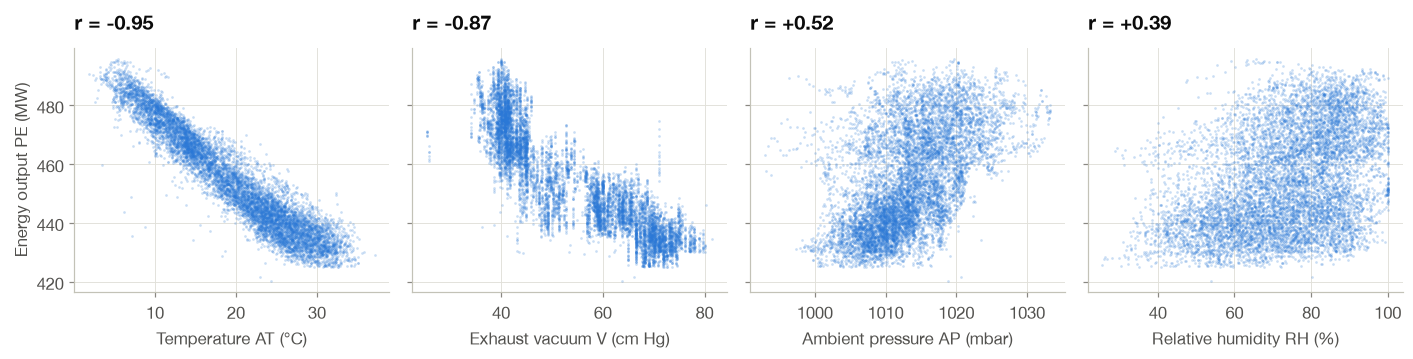

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharey=True)
labels = {"AT": "Temperature AT (°C)", "V": "Exhaust vacuum V (cm Hg)",
          "AP": "Ambient pressure AP (mbar)", "RH": "Relative humidity RH (%)"}
for ax, c in zip(axes, ["AT", "V", "AP", "RH"]):
    ax.scatter(df[c], df["PE"], s=3, alpha=0.25, color=BLUE, linewidths=0)
    r = df[[c, "PE"]].corr().iloc[0, 1]
    ax.set(xlabel=labels[c], title=f"r = {r:+.2f}")
axes[0].set_ylabel("Energy output PE (MW)")
save(fig, "cc_feature_vs_target")

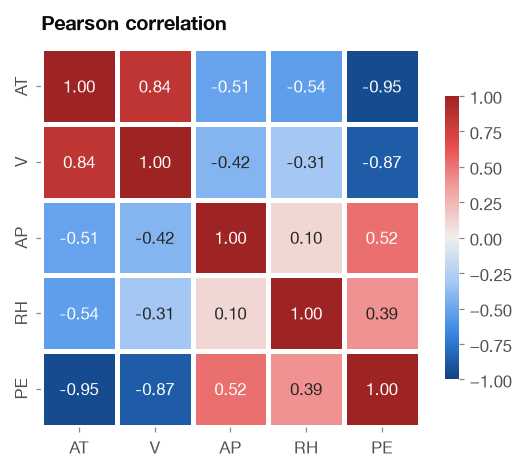

In [5]:
fig, ax = plt.subplots(figsize=(5.2, 4.3))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap=DIVERGING, vmin=-1, vmax=1, square=True,
            linewidths=2, linecolor=SURFACE, cbar_kws={"shrink": 0.75}, ax=ax)
ax.set(title="Pearson correlation")
ax.grid(False)
save(fig, "cc_correlation")

In [6]:
X = df[["AT", "V", "AP", "RH"]]
y = df["PE"]
Xc = np.column_stack([np.ones(len(X)), StandardScaler().fit_transform(X)])
vif = pd.Series([variance_inflation_factor(Xc, i + 1) for i in range(4)], index=X.columns, name="VIF")
vif.round(2)

AT    5.97
V     3.94
AP    1.45
RH    1.71
Name: VIF, dtype: float64

**Observations:** AT (r = −0.95) and V (−0.87) are strong, almost linear, negative drivers: hotter air is less dense,
so the gas turbine produces less power. AT and V are correlated with each other (r = 0.84; VIF: AT ≈ 6.0, V ≈ 3.9);
that is moderate multicollinearity: fine for prediction, but individual linear coefficients should be read with care.
The AT–PE relationship bends slightly, so non-linear models should beat a plain linear fit.

## 3. Train / test split and pipeline
- 80 / 20 split (`random_state = 42`); the test set is touched **only once** at the end.
- Scaling (`StandardScaler`) inside each pipeline so it is fitted on training folds only (no leakage).
- 5-fold cross-validation on the training set for model comparison.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
print(X_train.shape, X_test.shape)
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    "Linear Regression": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge (α=1)": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Lasso (α=0.01)": make_pipeline(StandardScaler(), Lasso(alpha=0.01)),
    "Polynomial (deg 3)": make_pipeline(StandardScaler(), PolynomialFeatures(3), LinearRegression()),
    "KNN (k=7)": make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=7, weights="distance")),
    "SVR (RBF)": make_pipeline(StandardScaler(), SVR(C=50, epsilon=0.5)),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=SEED),
    "Random Forest": RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=SEED),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=400, learning_rate=0.1, max_depth=4, random_state=SEED),
    "XGBoost": XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=6, subsample=0.8,
                            colsample_bytree=0.9, random_state=SEED, n_jobs=-1),
}

(7621, 4) (1906, 4)


## 4. Train and compare models

In [8]:
rows, fitted = [], {}
for name, model in models.items():
    cvres = cross_validate(model, X_train, y_train, cv=cv, n_jobs=-1,
                           scoring=["r2", "neg_root_mean_squared_error"])
    t0 = time.time()
    model.fit(X_train, y_train)
    fit_s = time.time() - t0
    pred = model.predict(X_test)
    fitted[name] = model
    rows.append({
        "Model": name,
        "CV R² (mean)": cvres["test_r2"].mean(), "CV R² (std)": cvres["test_r2"].std(),
        "CV RMSE": -cvres["test_neg_root_mean_squared_error"].mean(),
        "Train R²": r2_score(y_train, model.predict(X_train)),
        "Test MAE": mean_absolute_error(y_test, pred),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "Test R²": r2_score(y_test, pred),
        "Fit time (s)": fit_s,
    })
results = pd.DataFrame(rows).sort_values("Test RMSE").reset_index(drop=True)
results.round(4)

,Model,CV R² (mean),CV R² (std),CV RMSE,Train R²,Test MAE,Test RMSE,Test R²,Fit time (s)
0,XGBoost,0.9656,0.0026,3.1508,0.9885,2.2870,3.2821,0.9633,1.5885
1,Gradient Boosting,0.9623,0.0030,3.2992,0.9801,2.4410,3.4035,0.9606,6.1621
2,Random Forest,0.9598,0.0033,3.4053,0.9948,2.4089,3.4341,0.9599,2.3299
3,KNN (k=7),0.9510,0.0021,3.7651,1.0000,2.6506,3.7503,0.9521,0.0483
4,Decision Tree,0.9417,0.0037,4.1031,0.9682,2.9332,4.0754,0.9435,0.0363
5,SVR (RBF),0.9444,0.0035,4.0069,0.9469,3.0060,4.0771,0.9434,2.5807
6,Polynomial (deg 3),0.9404,0.0034,4.1490,0.9411,3.2693,4.2337,0.9390,0.0221
7,Lasso (α=0.01),0.9283,0.0034,4.5525,0.9284,3.6214,4.5874,0.9284,0.0057
8,Ridge (α=1),0.9283,0.0034,4.5525,0.9284,3.6216,4.5875,0.9284,0.0458
9,Linear Regression,0.9283,0.0034,4.5524,0.9284,3.6215,4.5875,0.9284,0.0401


## 5. Hyper-parameter tuning of the best family (XGBoost)

In [9]:
grid = GridSearchCV(
    XGBRegressor(random_state=SEED, n_jobs=-1, subsample=0.8),
    {"n_estimators": [600, 1200], "learning_rate": [0.03, 0.05], "max_depth": [5, 7],
     "colsample_bytree": [0.8, 1.0]},
    cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_, "| CV RMSE:", round(-grid.best_score_, 4))
tuned = grid.best_estimator_
pred = tuned.predict(X_test)
tuned_row = {"Model": "XGBoost (tuned)", "CV R² (mean)": np.nan, "CV R² (std)": np.nan,
             "CV RMSE": -grid.best_score_, "Train R²": r2_score(y_train, tuned.predict(X_train)),
             "Test MAE": mean_absolute_error(y_test, pred),
             "Test RMSE": np.sqrt(mean_squared_error(y_test, pred)), "Test R²": r2_score(y_test, pred),
             "Fit time (s)": np.nan}
cvt = cross_validate(tuned, X_train, y_train, cv=cv, scoring="r2", n_jobs=-1)
tuned_row["CV R² (mean)"], tuned_row["CV R² (std)"] = cvt["test_score"].mean(), cvt["test_score"].std()
fitted["XGBoost (tuned)"] = tuned
results = pd.concat([results, pd.DataFrame([tuned_row])]).sort_values("Test RMSE").reset_index(drop=True)
results.to_csv(MODELS / "regression_results.csv", index=False)
results.round(4)

Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 7, 'n_estimators': 1200} | CV RMSE: 3.089


,Model,CV R² (mean),CV R² (std),CV RMSE,Train R²,Test MAE,Test RMSE,Test R²,Fit time (s)
0,XGBoost (tuned),0.9670,0.0026,3.0890,0.9958,2.1656,3.1711,0.9658,NaN
1,XGBoost,0.9656,0.0026,3.1508,0.9885,2.2870,3.2821,0.9633,1.5885
2,Gradient Boosting,0.9623,0.0030,3.2992,0.9801,2.4410,3.4035,0.9606,6.1621
3,Random Forest,0.9598,0.0033,3.4053,0.9948,2.4089,3.4341,0.9599,2.3299
4,KNN (k=7),0.9510,0.0021,3.7651,1.0000,2.6506,3.7503,0.9521,0.0483
5,Decision Tree,0.9417,0.0037,4.1031,0.9682,2.9332,4.0754,0.9435,0.0363
6,SVR (RBF),0.9444,0.0035,4.0069,0.9469,3.0060,4.0771,0.9434,2.5807
7,Polynomial (deg 3),0.9404,0.0034,4.1490,0.9411,3.2693,4.2337,0.9390,0.0221
8,Lasso (α=0.01),0.9283,0.0034,4.5525,0.9284,3.6214,4.5874,0.9284,0.0057
9,Ridge (α=1),0.9283,0.0034,4.5525,0.9284,3.6216,4.5875,0.9284,0.0458


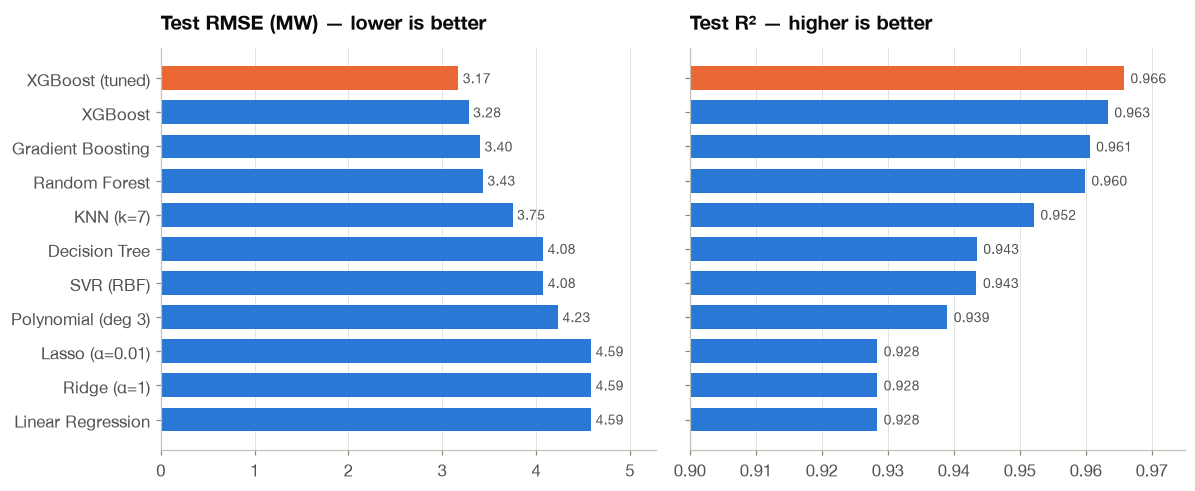

In [10]:
plot = results.sort_values("Test RMSE", ascending=False)
best_name = results.iloc[0]["Model"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
colors = [SERIES[1] if m == best_name else BLUE for m in plot["Model"]]
axes[0].barh(plot["Model"], plot["Test RMSE"], color=colors, height=0.7)
for yv, v in enumerate(plot["Test RMSE"]):
    axes[0].text(v + 0.05, yv, f"{v:.2f}", va="center", fontsize=9, color=INK_2)
axes[0].set(title="Test RMSE (MW) — lower is better", xlim=(0, plot["Test RMSE"].max() * 1.15))
axes[1].barh(plot["Model"], plot["Test R²"], color=colors, height=0.7)
for yv, v in enumerate(plot["Test R²"]):
    axes[1].text(v + 0.001, yv, f"{v:.3f}", va="center", fontsize=9, color=INK_2)
axes[1].set(title="Test R² — higher is better", xlim=(0.9, 0.975))
for ax in axes:
    ax.grid(axis="y", visible=False)
save(fig, "cc_model_comparison")

## 6. Diagnostics of the best model

findfont: Failed to find font weight semibold for Helvetica Neue, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


Residual mean 0.017, std 3.172; 92.5% of predictions within ±5 MW


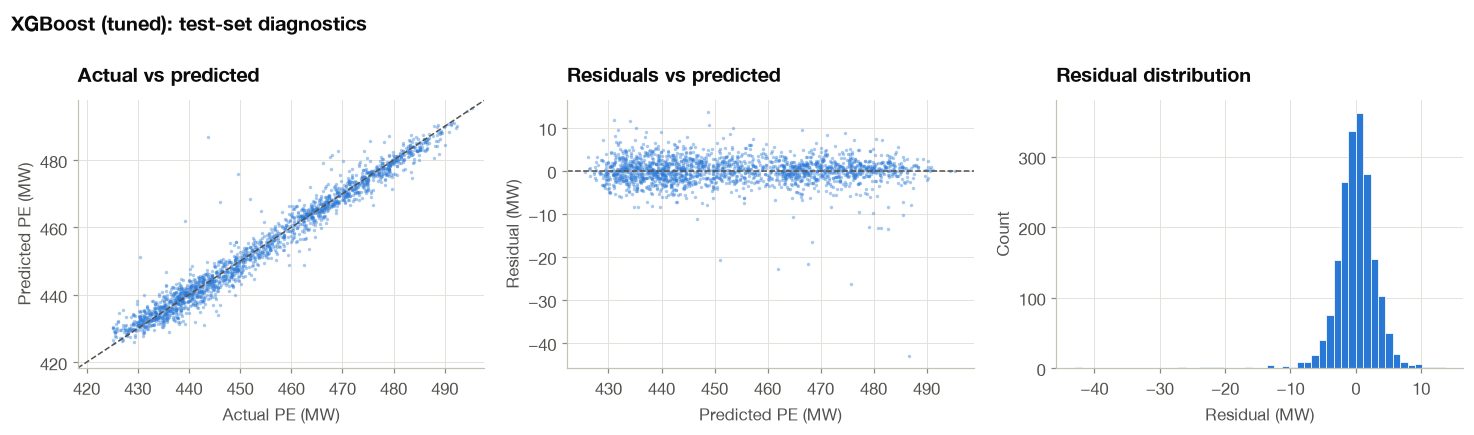

In [11]:
best = fitted[best_name]
pred = best.predict(X_test)
res = y_test - pred
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))
axes[0].scatter(y_test, pred, s=5, alpha=0.4, color=BLUE, linewidths=0)
lims = [y.min() - 2, y.max() + 2]
axes[0].plot(lims, lims, color=INK_2, lw=1, ls="--")
axes[0].set(xlim=lims, ylim=lims, xlabel="Actual PE (MW)", ylabel="Predicted PE (MW)", title="Actual vs predicted")
axes[1].scatter(pred, res, s=5, alpha=0.4, color=BLUE, linewidths=0)
axes[1].axhline(0, color=INK_2, lw=1, ls="--")
axes[1].set(xlabel="Predicted PE (MW)", ylabel="Residual (MW)", title="Residuals vs predicted")
axes[2].hist(res, bins=50, color=BLUE, edgecolor=SURFACE, linewidth=0.5)
axes[2].set(xlabel="Residual (MW)", ylabel="Count", title="Residual distribution")
fig.suptitle(f"{best_name}: test-set diagnostics", x=0.01, ha="left", fontweight="semibold")
save(fig, "cc_best_diagnostics")
print(f"Residual mean {res.mean():.3f}, std {res.std():.3f}; "
      f"{(res.abs() <= 5).mean():.1%} of predictions within ±5 MW")

,permutation_importance,linear_coef
AP,0.027,0.374
AT,1.365,-14.670
RH,0.023,-2.298
V,0.125,-2.980


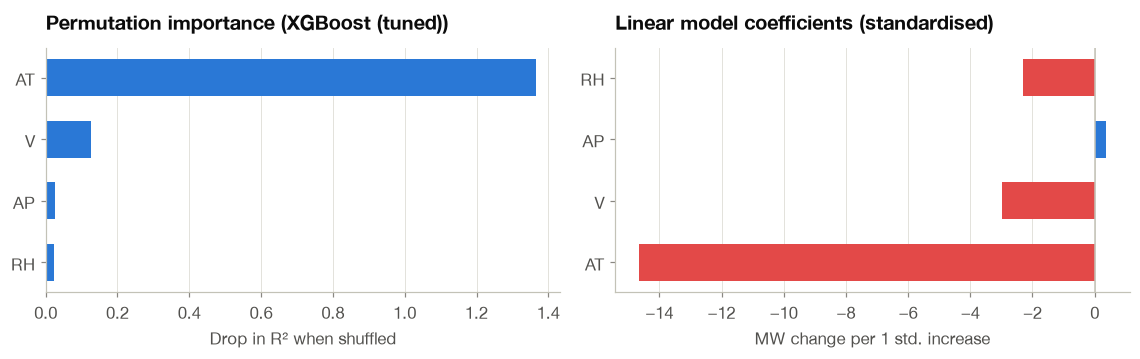

In [12]:
perm = permutation_importance(best, X_test, y_test, n_repeats=15, random_state=SEED, scoring="r2")
imp = pd.Series(perm.importances_mean, index=X.columns).sort_values()
lin = fitted["Linear Regression"][-1]
coef = pd.Series(lin.coef_, index=X.columns)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4))
axes[0].barh(imp.index, imp.values, color=BLUE, height=0.6)
axes[0].set(title=f"Permutation importance ({best_name})", xlabel="Drop in R² when shuffled")
axes[1].barh(coef.index, coef.values, color=[SERIES[7] if v < 0 else BLUE for v in coef.values], height=0.6)
axes[1].axvline(0, color=AXIS, lw=1)
axes[1].set(title="Linear model coefficients (standardised)", xlabel="MW change per 1 std. increase")
for ax in axes:
    ax.grid(axis="y", visible=False)
save(fig, "cc_feature_importance")
pd.DataFrame({"permutation_importance": imp, "linear_coef": coef}).round(3)

## 7. Results summary

In [13]:
lr = results.set_index("Model").loc["Linear Regression"]
b = results.iloc[0]
summary = {
    "rows": len(df), "train": len(X_train), "test": len(X_test),
    "best_model": best_name, "best_params": grid.best_params_,
    "best_rmse": b["Test RMSE"], "best_mae": b["Test MAE"], "best_r2": b["Test R²"],
    "best_cv_r2": b["CV R² (mean)"], "best_train_r2": b["Train R²"],
    "lr_rmse": lr["Test RMSE"], "lr_mae": lr["Test MAE"], "lr_r2": lr["Test R²"],
    "rmse_improvement_pct": (1 - b["Test RMSE"] / lr["Test RMSE"]) * 100,
    "within_5mw_pct": (res.abs() <= 5).mean() * 100,
    "pe_range": [float(y.min()), float(y.max())], "pe_std": float(y.std()),
    "importance": imp.sort_values(ascending=False).to_dict(), "linear_coef": coef.to_dict(),
    "vif": vif.to_dict(), "corr_with_pe": df.corr()["PE"].drop("PE").to_dict(),
}
save_json(summary, "regression_summary")
pd.Series(summary)

rows                                                                 9527
train                                                                7621
test                                                                 1906
best_model                                                XGBoost (tuned)
best_params             {'colsample_bytree': 1.0, 'learning_rate': 0.0...
best_rmse                                                        3.171132
best_mae                                                         2.165646
best_r2                                                          0.965783
best_cv_r2                                                       0.966961
best_train_r2                                                    0.995779
lr_rmse                                                          4.587499
lr_mae                                                           3.621467
lr_r2                                                            0.928392
rmse_improvement_pct                  

**Interpretation**
1. **Tuned XGBoost is the best model**: test RMSE ≈ 3.17 MW, MAE ≈ 2.17 MW, R² ≈ 0.966, about **31 % lower RMSE than Linear Regression** (4.59 MW).
   92 % of hourly predictions fall within ±5 MW of the true output (the output ranges 420–496 MW).
2. **Linear models already reach R² ≈ 0.93** because AT and V act almost linearly; tree ensembles win by capturing the curvature and AT×V interaction.
3. **Ridge/Lasso ≈ plain Linear Regression**: with only 4 features and ~7.6K rows there is nothing to regularise; multicollinearity (VIF ≤ 6) is not severe.
4. **Generalisation**: CV R² (0.967) ≈ test R² (0.966) with tiny std (0.003), so results are stable and not a lucky split. Tree models have higher train R² (0.99+) — some memorisation, but the CV confirms it does not hurt test error.
5. **Ambient temperature (AT) dominates**: shuffling it destroys the model (R² drop > 1); V is second; AP and RH add small corrections. Physically, hotter, less dense air → less turbine power (≈ −14.7 MW per 1 std increase in AT in the linear model).
6. **Residuals** are centred at 0 and roughly symmetric with no pattern vs predicted value, so there is no systematic bias.